## Bank Custumers - Churn Prediction with XGBoost and MLP models

#### Objectives
   1. Identify variables which have high impact on Y variable
   2. Developper un modèle de prediction
   3. Mesurer les metrics pour comparer les performances entre ML et Deep Learning

#### Summary
- Libraries
- Data set import
- Cleaning
- Data Exploration & Treatment
    - Data Cleaning : Missing Values, Outliers...
    

In [ ]:
%pip install optuna xgboost scikit-learn

## Libraries

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from tabulate import tabulate
#from dython.nominal import associations
import optuna
import xgboost as xgb
from sklearn.model_selection import cross_val_score

### Dataset Import & Data Cleaning

In [23]:
df = pd.read_csv("Churn_Modelling.csv")

print("Shape dataset:",df.shape) # 14 variables # 10 000 individuals

# Identify missing values
print("Missing values:",df.isnull().sum()) #No missing values

# Identify duplicates
print("Duplicates:",df.duplicated().sum())

# Drop the unnecessary variables
df = df.drop(columns=['RowNumber', 'CustomerId', 'Surname'], axis=1)

# Change variable name "Exited" to "Churn"
df = df.rename(columns={'Exited': 'Churn'})

# Convert to categorial variable
cols_cat = ['Geography', 'Gender','IsActiveMember', 'HasCrCard', 'NumOfProducts', 'Churn']
df[cols_cat] = df[cols_cat].astype('category')

## Print the data frame
print(tabulate(df, headers='keys', tablefmt='pretty'))


Shape dataset: (10000, 14)
Missing values: RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64
Duplicates: 0
+------+-------------+-----------+--------+-----+--------+-----------+---------------+-----------+----------------+-----------------+-------+
|      | CreditScore | Geography | Gender | Age | Tenure |  Balance  | NumOfProducts | HasCrCard | IsActiveMember | EstimatedSalary | Churn |
+------+-------------+-----------+--------+-----+--------+-----------+---------------+-----------+----------------+-----------------+-------+
|  0   |     619     |  France   | Female | 42  |   2    |    0.0    |       1       |     1     |       1        |    101348.88    |   1   |
|  1   |     608     |   Spain   | Female | 41  |   1    | 83807.86 

In [24]:
# Description variables
print(df.describe())
print(df.describe(include=['object', 'category']))

        CreditScore           Age        Tenure        Balance  \
count  10000.000000  10000.000000  10000.000000   10000.000000   
mean     650.528800     38.921800      5.012800   76485.889288   
std       96.653299     10.487806      2.892174   62397.405202   
min      350.000000     18.000000      0.000000       0.000000   
25%      584.000000     32.000000      3.000000       0.000000   
50%      652.000000     37.000000      5.000000   97198.540000   
75%      718.000000     44.000000      7.000000  127644.240000   
max      850.000000     92.000000     10.000000  250898.090000   

       EstimatedSalary  
count     10000.000000  
mean     100090.239881  
std       57510.492818  
min          11.580000  
25%       51002.110000  
50%      100193.915000  
75%      149388.247500  
max      199992.480000  
       Geography Gender  NumOfProducts  HasCrCard  IsActiveMember  Churn
count      10000  10000          10000      10000           10000  10000
unique         3      2           

#### Variables :
- **CreditScore** = A numerical score representing the customer’s creditworthiness (higher = better credit profile)  
- **Geography** = Indicates the country or region where the customer lives (e.g., France, Germany, Spain)  
- **Gender** = Indicates the customer’s gender (e.g., Male or Female)  
- **Age** = The customer’s age in years  
- **Tenure** = Number of years the customer has been with the bank  
- **Balance** = The amount of money the customer currently has in their bank account(s)  
- **NumOfProducts** = The number of bank products the customer is using (e.g., savings, credit card, loan)  
- **HasCrCard** = Indicates whether the customer owns a credit card from the bank (1 = Yes, 0 = No)  
- **IsActiveMember** = Indicates whether the customer is an active user of the bank’s services (1 = Active, 0 = Inactive)  
- **EstimatedSalary** = The customer’s estimated annual income  
- **Churn** = Target variable indicating whether the customer has left the bank (1 = Churned, 0 = Retained)



### Explonatory Data Analysis (EDA)

#### 1. Univariate Analysis

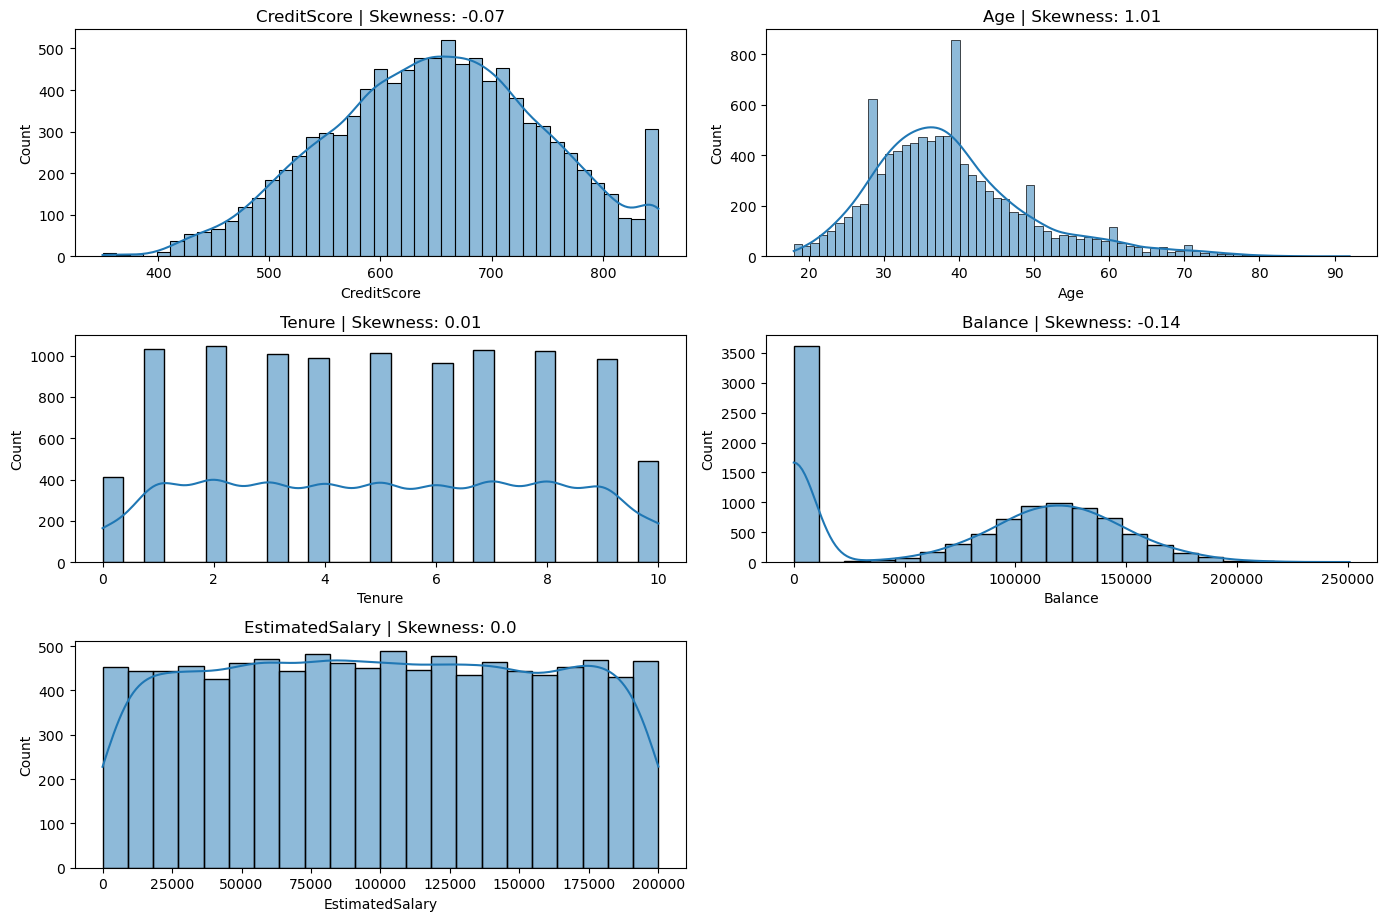

In [ ]:
## KERNEL DENSITY PLOT -- NUMERICAL VARIABLES
numerical_cols = df.select_dtypes(include=['int64', 'float64']).columns

plt.figure(figsize=(14, len(numerical_cols) * 3))
for idx, feature in enumerate(numerical_cols, 1):
    plt.subplot(len(numerical_cols), 2, idx)
    sns.histplot(df[feature], kde=True)
    plt.title(f"{feature} | Skewness: {round(df[feature].skew(), 2)}")

plt.tight_layout()
plt.show()

The features in the dataset with a skewness of 0 shows a symmetrical distribution. If the skewness is 1 or above it suggests a positively skewed (right-skewed) distribution. In a right-skewed distribution the tail extends more to the right which shows the presence of extremely high values.

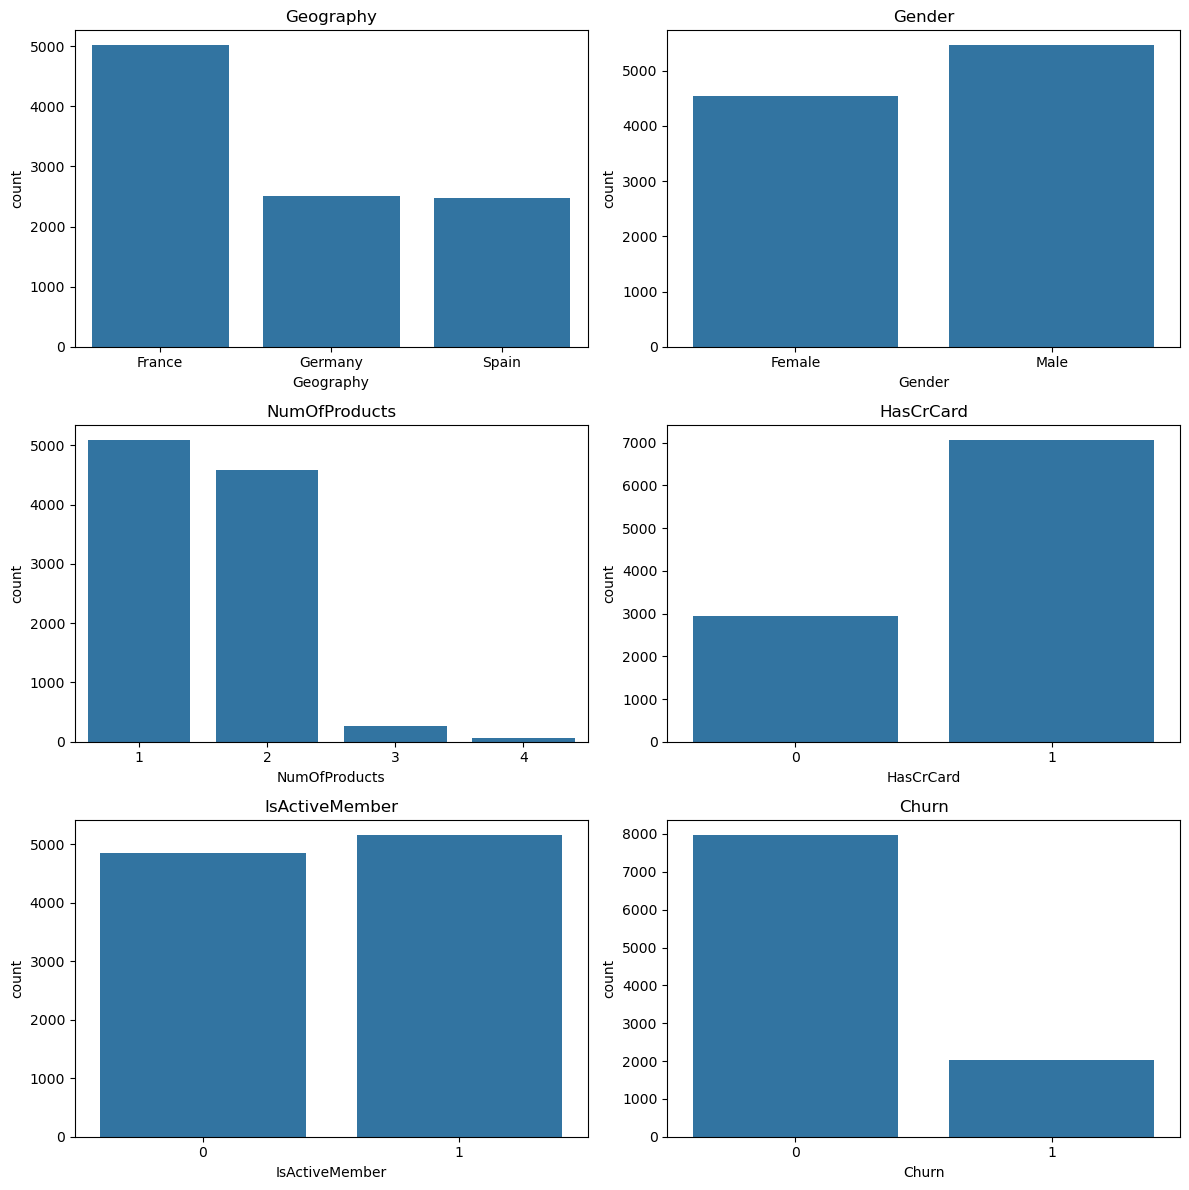

In [33]:
## BAR PLOTS -- CATEGORICAL VARIABLES (compatible future)
categorical_cols = df.select_dtypes(include=['category']).columns

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, feature in enumerate(categorical_cols):
    sns.countplot(x=feature, data=df, ax=axes[i])
    axes[i].set_title(feature)

plt.tight_layout()
plt.show()



#### 2. Bivariate Analysis

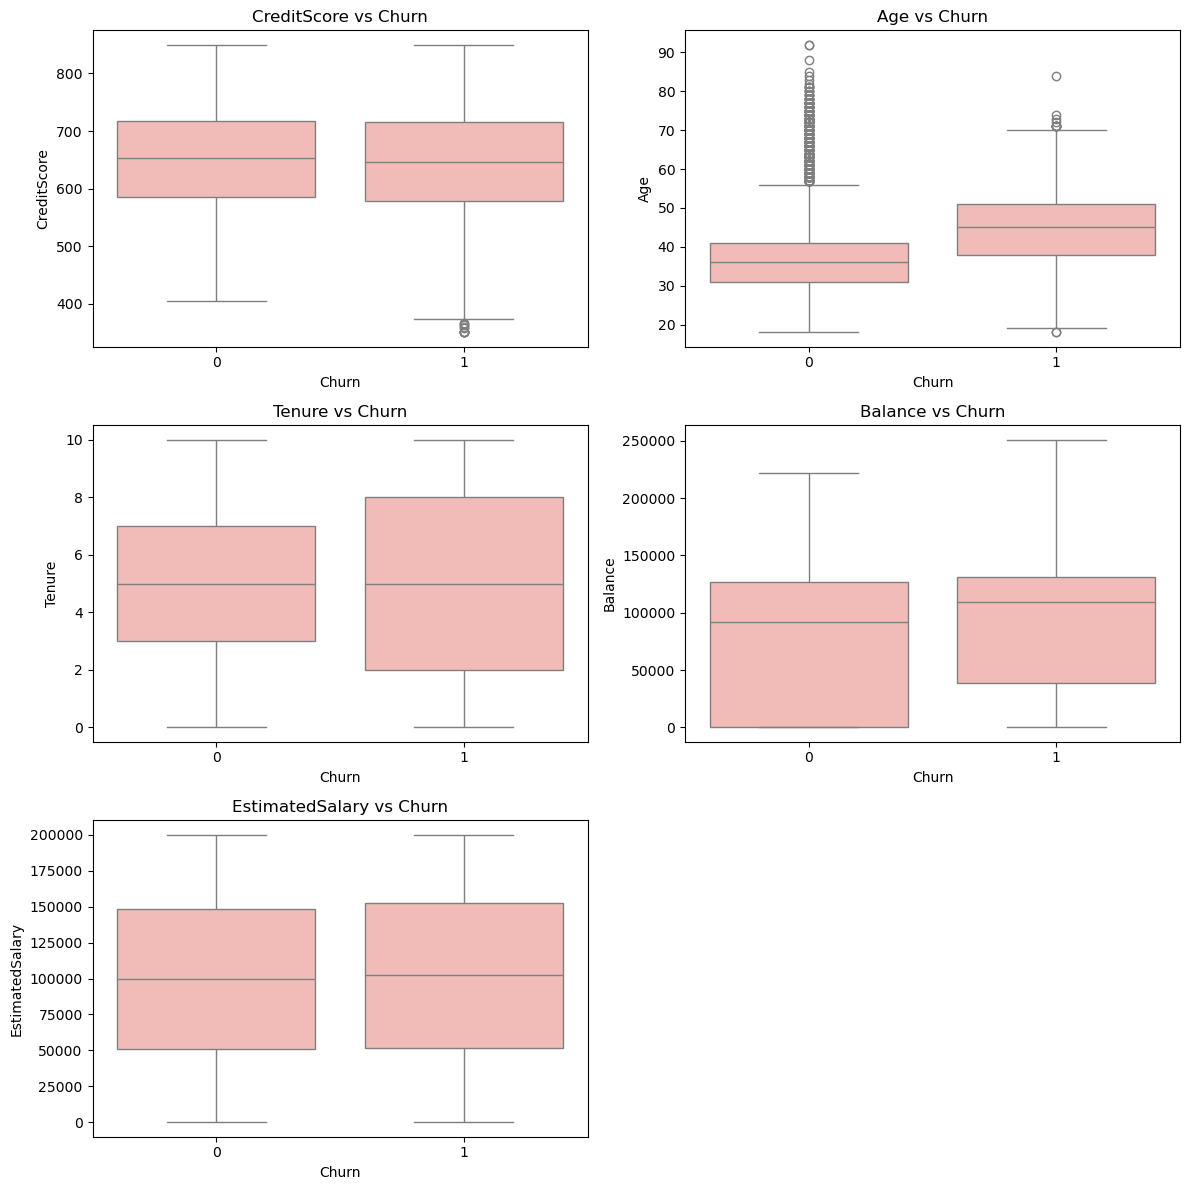

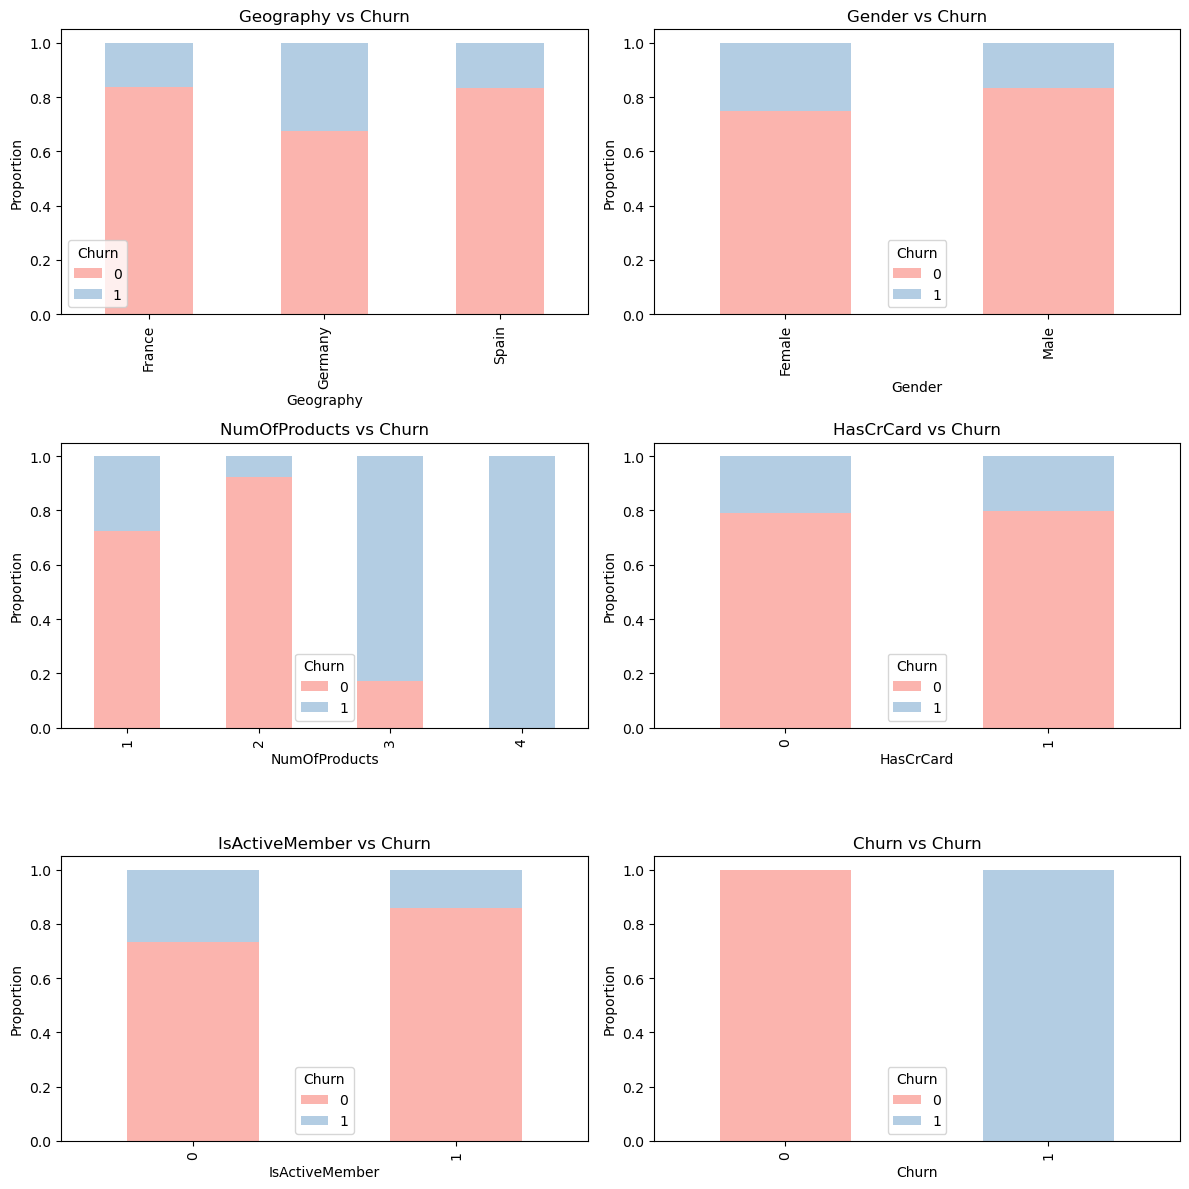

In [38]:
## 1. Variables numériques vs Churn (3x2)

numerical_cols = df.select_dtypes(include=['float64', 'int64']).columns

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, feature in enumerate(numerical_cols):
    sns.boxplot(x='Churn', y=feature, data=df, ax=axes[i])
    axes[i].set_title(f'{feature} vs Churn')

# Cacher les subplots vides s'il y en a moins de 6
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()


## 2. Variables catégorielles vs Churn (3x2)

fig, axes = plt.subplots(3, 2, figsize=(12, 12))
axes = axes.flatten()

for i, feature in enumerate(categorical_cols):
    ct = pd.crosstab(df[feature], df['Churn'], normalize='index')
    ct.plot(kind='bar', stacked=True, ax=axes[i])
    axes[i].set_title(f'{feature} vs Churn')
    axes[i].set_ylabel('Proportion')
    axes[i].legend(title='Churn')

# Cacher les subplots vides s'il y en a moins de 6
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

#### 3. Correlation

In [ ]:
# Détecte automatiquement les types et affiche la heatmap
#associations(df, 
 #            nominal_columns='auto',
  #           plot=True, 
   #          cmap='coolwarm',
    #         figsize=(12, 10))

### Prepare set for ML

In [ ]:
X = df.drop('Churn', axis=1)
y = df['Churn']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Scalings
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

NameError: name 'train_test_split' is not defined

### Hyperparameter Optimization (Optuna)

In [ ]:
# Fonction objective pour XGBoost
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 400),
        'max_depth': trial.suggest_int('max_depth', 3, 20),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample': trial.suggest_float('subsample', 0.6, 1.0),
        'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
        'min_child_weight': trial.suggest_int('min_child_weight', 1, 10),
        'gamma': trial.suggest_float('gamma', 0, 5),
        'reg_alpha': trial.suggest_float('reg_alpha', 0, 10),
        'reg_lambda': trial.suggest_float('reg_lambda', 0, 10),
        'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1, 10),  # pour classes déséquilibrées
        'tree_method': 'hist',  # plus rapide
        'random_state': 42
    }
    
    model = xgb.XGBClassifier(**params, eval_metric='logloss')
    
    # Using F1-score for cross-validation due to imbalanced classes
    score = cross_val_score(model, X_train, y_train, n_jobs=-1, cv=3, scoring='f1').mean()
    return score

print("\n--- Searching for Optimal Parameters ---")
study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=25)

print(f"\nBest F1-score: {study.best_value:.4f}")
print(f"Optimal Parameters: {study.best_params}")

# Entraîner le modèle final avec les meilleurs paramètres
best_model = xgb.XGBClassifier(**study.best_params, random_state=42, eval_metric='logloss')
best_model.fit(X_train, y_train)